# Notebook 04 — Advanced NLP Analysis & Supervised Classification

**Project:** Thematic Evolution of French Electoral Manifestos (1981–1993)  
**Course:** Machine Learning for NLP — ENSAE Paris, 2025–2026  
**Author:** Gabriel Orsatti

---

## Overview

This notebook builds on the topic model trained in Notebook 03 to perform four advanced analyses:

| Section | Method | Goal |
|---------|--------|------|
| **1 — Semantic Mapping** | t-SNE on LDA/NMF topic vectors | 2-D projection of the 12k-document corpus, coloured by party then by topic |
| **2 — Thematic Sentiment** | TF-IDF + log-odds ratio | Per-topic vocabulary used by each party (e.g. "Europe" through PS vs FN eyes) |
| **3 — Discourse vs Reality** | INSEE unemployment + Pearson correlation | Do employment-topic frequencies track actual departmental unemployment? |
| **4 — Supervised Classification** | Logistic Regression on TF-IDF | Can text alone predict the political family? Confusion matrix + F1 scores |
| **5 — Summary** | — | Synthesis and conclusions |

These analyses operationalise methods from lectures 3 (TF-IDF), 6 (topic modelling), and 8 (supervised text classification) of the ENSAE NLP course.

---

---
## 0. Environment & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager
import seaborn as sns
from pathlib import Path
import re, string, os, pickle, json, warnings
from collections import Counter, defaultdict
from itertools import combinations
import urllib.request

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, ConfusionMatrixDisplay)
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder
from scipy.stats import pearsonr, spearmanr

warnings.filterwarnings('ignore')
print("✓ Imports OK")

✓ Imports OK


In [2]:
# ── Visual identity (consistent with NB02 & NB03) ──────────────────────────────
FONT_DIR = os.path.expanduser("~/.fonts")
os.makedirs(FONT_DIR, exist_ok=True)

for name, url in {
    "Playfair Display": "https://github.com/google/fonts/raw/main/ofl/playfairdisplay/PlayfairDisplay%5Bwght%5D.ttf",
    "Source Sans 3":    "https://github.com/google/fonts/raw/main/ofl/sourcesans3/SourceSans3%5Bwght%5D.ttf",
}.items():
    path = os.path.join(FONT_DIR, f"{name}.ttf")
    if not os.path.exists(path):
        urllib.request.urlretrieve(url, path)
        print(f"Downloaded: {name}")

font_manager.fontManager.addfont(os.path.join(FONT_DIR, "Playfair Display.ttf"))
font_manager.fontManager.addfont(os.path.join(FONT_DIR, "Source Sans 3.ttf"))

FONT_TITLE = "Playfair Display"
FONT_BODY  = "Source Sans 3"
BG_COLOR   = "#FAF8F3"
TEXT_COLOR = "#2C2C2C"

PARTY_COLORS = {
    "PCF":          "#D32F2F",
    "PS":           "#E57373",
    "Radicaux":     "#EF9A9A",
    "Ecologistes":  "#66BB6A",
    "UDF":          "#90CAF9",
    "RPR":          "#1565C0",
    "FN":           "#212121",
    "Non mentionné":"#BDBDBD",
    "Autre":        "#A89F96",
}

YEAR_COLORS = {"1981": "#C0392B", "1988": "#2980B9", "1993": "#27AE60"}

mpl.rcParams.update({
    "figure.facecolor":  BG_COLOR,
    "axes.facecolor":    BG_COLOR,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.25,
    "grid.color":        "#CCCCCC",
    "font.family":       "sans-serif",
    "font.sans-serif":   [FONT_BODY, "DejaVu Sans"],
})
print("✓ Visual style configured")

✓ Visual style configured


In [3]:
# ── Load pickled outputs from NB03 ──────────────────────────────────────────────
DATA_DIR = Path("../data")

df_topic = pd.read_pickle(DATA_DIR / "df_topics.pkl")

with open(DATA_DIR / "models_topic.pkl", "rb") as f:
    models = pickle.load(f)

lda_final          = models["lda_final"]
nmf_final          = models["nmf_final"]
tfidf_vec_clean    = models["tfidf_vectorizer"]
gensim_dictionary  = models["gensim_dictionary"]
K_LDA              = models["K_LDA"]
K_NMF              = models["K_NMF"]
PRIMARY            = models["PRIMARY"]
TOPIC_NAMES_LDA    = models["TOPIC_NAMES_LDA"]
TOPIC_NAMES_NMF    = models["TOPIC_NAMES_NMF"]

topic_col = "lda_topic_name" if PRIMARY == "LDA" else "nmf_topic_name"

print(f"✓ DataFrame loaded: {len(df_topic):,} documents")
print(f"✓ Primary model   : {PRIMARY} (k={K_LDA if PRIMARY=='LDA' else K_NMF})")
print(f"✓ Topic column    : '{topic_col}'")
df_topic[["year", "parti_famille", topic_col]].head()

✓ DataFrame loaded: 12,419 documents
✓ Primary model   : LDA (k=11)
✓ Topic column    : 'lda_topic_name'


,year,parti_famille,lda_topic_name
0,1993,Non mentionné,Electoral alliance & institutional trust
1,1993,PCF,Left-right cleavage & partisan positioning
2,1993,Ecologistes,"Ecology, democracy & citizen engagement"
3,1993,RPR,Electoral alliance & institutional trust
4,1993,Ecologistes,Animal welfare (micro-party artifact)


In [4]:
# ── Rebuild topic document-distribution matrix (W matrix) ──────────────────────
# The W matrix gives each document's weight over every topic — the input to t-SNE.
# For LDA we use gensim inference; for NMF it was produced directly during fit.

from gensim import corpora

if PRIMARY == "LDA":
    # Re-derive document-topic distributions via gensim inference
    with open("../data/checkpoints/lemmatized_tokens.json") as f:
        token_lists = json.load(f)

    # Align token_lists with df_topic (same filtering was applied in NB03)
    token_lists = token_lists[:len(df_topic)]   # safety guard

    W_matrix = np.zeros((len(df_topic), K_LDA))
    for i, tokens in enumerate(token_lists):
        bow = gensim_dictionary.doc2bow(tokens)
        vec = dict(lda_final.get_document_topics(bow, minimum_probability=0))
        for topic_id, weight in vec.items():
            if topic_id < K_LDA:
                W_matrix[i, topic_id] = weight
else:
    # NMF: W was the output of fit_transform — recompute from TF-IDF
    tfidf_matrix = tfidf_vec_clean.transform(df_topic["text_clean"])
    W_matrix = nmf_final.transform(tfidf_matrix)
    # Normalize rows to sum to 1 (NMF does not guarantee this)
    row_sums = W_matrix.sum(axis=1, keepdims=True)
    W_matrix = np.where(row_sums > 0, W_matrix / row_sums, 0)

print(f"✓ W_matrix shape  : {W_matrix.shape}  (documents × topics)")
print(f"  Row-sum stats   : min={W_matrix.sum(axis=1).min():.3f}  "
      f"max={W_matrix.sum(axis=1).max():.3f}  "
      f"mean={W_matrix.sum(axis=1).mean():.3f}")

✓ W_matrix shape  : (12419, 11)  (documents × topics)
  Row-sum stats   : min=1.000  max=1.000  mean=1.000


---
## 1. Semantic Mapping — t-SNE Projection

### 1.1 Rationale

The topic-distribution vector $\theta_d \in \mathbb{R}^K$ (the row of the W matrix) is a low-dimensional summary of each document's thematic content. t-SNE (van der Maaten & Hinton, 2008) projects this K-dimensional space into 2-D while preserving local neighbourhood structure — documents with similar thematic profiles cluster together.

The course (*Lecture 6, slide 15*) notes that such semantic maps make latent structure interpretable: we expect documents from the same party or same dominant topic to form visible clusters in the 2-D plane.

**Implementation note:** We run t-SNE with `perplexity=50`, which trades local/global balance appropriately for a corpus of ~12k documents. We use the **cosine distance** on normalized topic vectors (via PCA initialisation) to avoid scale artifacts.

### 1.2 Computing the embedding

In [5]:
import sklearn
from packaging.version import Version

CHECKPOINT_TSNE = Path("../data/checkpoints/tsne_embedding.npy")

if CHECKPOINT_TSNE.exists():
    Z_tsne = np.load(CHECKPOINT_TSNE)
    print(f"✓ t-SNE loaded from cache  shape={Z_tsne.shape}")
else:
    print("Running t-SNE on W_matrix …  (may take 3–5 min for 12k docs)")

    # "n_iter" was renamed to "max_iter" in scikit-learn 1.2
    iter_kwarg = "max_iter" if Version(sklearn.__version__) >= Version("1.2") else "n_iter"

    tsne = TSNE(
        n_components=2,
        perplexity=50,
        **{iter_kwarg: 1000},
        learning_rate="auto",
        init="pca",
        metric="cosine",
        random_state=42,
        n_jobs=-1,
        verbose=1,
    )
    Z_tsne = tsne.fit_transform(W_matrix)
    np.save(CHECKPOINT_TSNE, Z_tsne)
    print(f"✓ t-SNE computed  KL divergence={tsne.kl_divergence_:.4f}")

df_topic["tsne_x"] = Z_tsne[:, 0]
df_topic["tsne_y"] = Z_tsne[:, 1]
print(f"  Coordinates added to df_topic  (sklearn {sklearn.__version__})")

Running t-SNE on W_matrix …  (may take 3–5 min for 12k docs)
[t-SNE] Computing 151 nearest neighbors...
[t-SNE] Indexed 12419 samples in 0.000s...
[t-SNE] Computed neighbors for 12419 samples in 31.126s...
[t-SNE] Computed conditional probabilities for sample 1000 / 12419
[t-SNE] Computed conditional probabilities for sample 2000 / 12419
[t-SNE] Computed conditional probabilities for sample 3000 / 12419
[t-SNE] Computed conditional probabilities for sample 4000 / 12419
[t-SNE] Computed conditional probabilities for sample 5000 / 12419
[t-SNE] Computed conditional probabilities for sample 6000 / 12419
[t-SNE] Computed conditional probabilities for sample 7000 / 12419
[t-SNE] Computed conditional probabilities for sample 8000 / 12419
[t-SNE] Computed conditional probabilities for sample 9000 / 12419
[t-SNE] Computed conditional probabilities for sample 10000 / 12419
[t-SNE] Computed conditional probabilities for sample 11000 / 12419
[t-SNE] Computed conditional probabilities for sample 1

### 1.3 Map coloured by political family

Each point is one electoral manifesto. The colour encodes the candidate's political family as defined in Notebook 02.

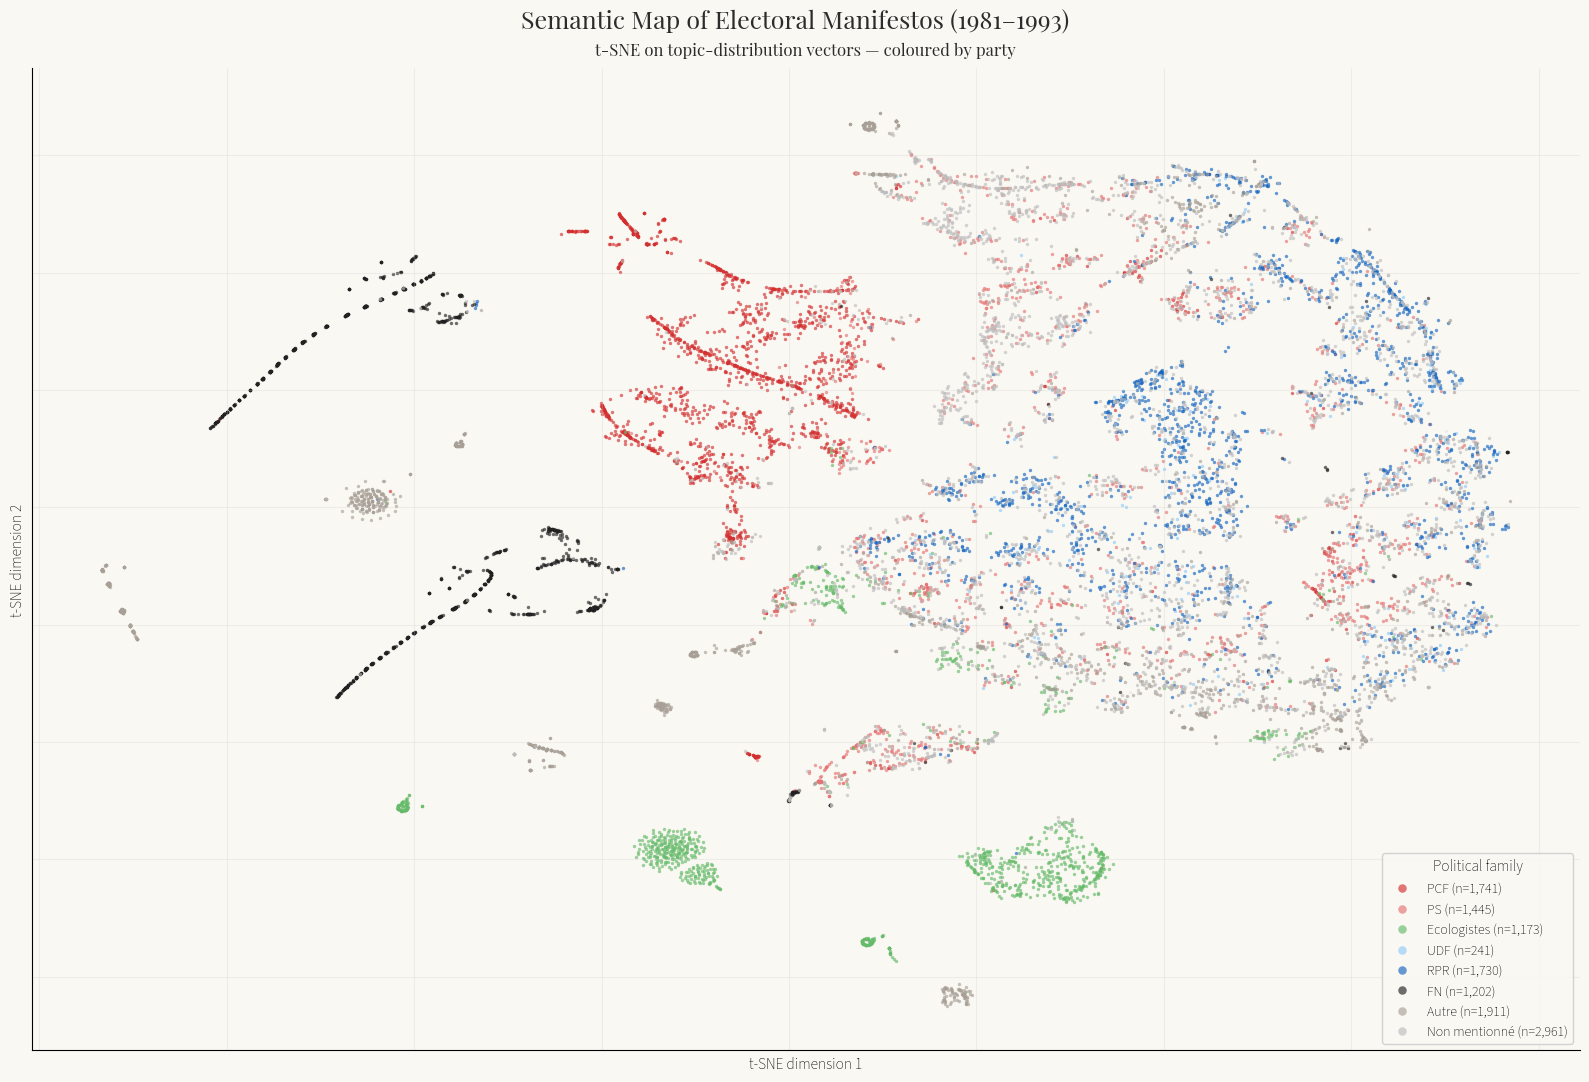

Saved: ../data/tsne_by_party.png


In [9]:
fig, ax = plt.subplots(figsize=(16, 11))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

main_parties = ["PCF", "PS", "Ecologistes", "UDF", "RPR", "FN", "Autre", "Non mentionné"]
other_mask   = ~df_topic["parti_famille"].isin(main_parties)

# Plot "other" first as background
ax.scatter(
    df_topic.loc[other_mask, "tsne_x"],
    df_topic.loc[other_mask, "tsne_y"],
    c="#CCCCCC", s=4, alpha=0.3, linewidths=0, label=None, rasterized=True
)

for party in main_parties:
    mask = df_topic["parti_famille"] == party
    if mask.sum() == 0:
        continue
    ax.scatter(
        df_topic.loc[mask, "tsne_x"],
        df_topic.loc[mask, "tsne_y"],
        c=PARTY_COLORS.get(party, "#A89F96"),
        s=6, alpha=0.65, linewidths=0,
        label=f"{party} (n={mask.sum():,})",
        rasterized=True,
    )

ax.legend(
    loc="lower right", frameon=True,
    framealpha=0.85, facecolor=BG_COLOR, edgecolor="#CCCCCC",
    fontsize=10, markerscale=2.5, title="Political family",
    title_fontsize=11,
)
fig.suptitle(
    "Semantic Map of Electoral Manifestos (1981–1993)",
    fontsize=18, fontweight="bold", fontfamily=FONT_TITLE, color=TEXT_COLOR
)

ax.set_title(
    "t-SNE on topic-distribution vectors — coloured by party",
    fontsize=12, fontfamily=FONT_TITLE, color=TEXT_COLOR, pad=10
)
ax.set_xlabel("t-SNE dimension 1", fontsize=11)
ax.set_ylabel("t-SNE dimension 2", fontsize=11)
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

plt.tight_layout()
plt.savefig("../data/tsne_by_party.png", dpi=200, bbox_inches="tight", facecolor=BG_COLOR)
plt.show()
print("Saved: ../data/tsne_by_party.png")

### 1.4 Map coloured by dominant topic

The same 2-D projection, this time coloured by each document's **dominant topic** (the topic with the highest weight in its $\theta_d$ vector). This reveals the thematic geography of the corpus and shows how topics relate to each other geometrically.

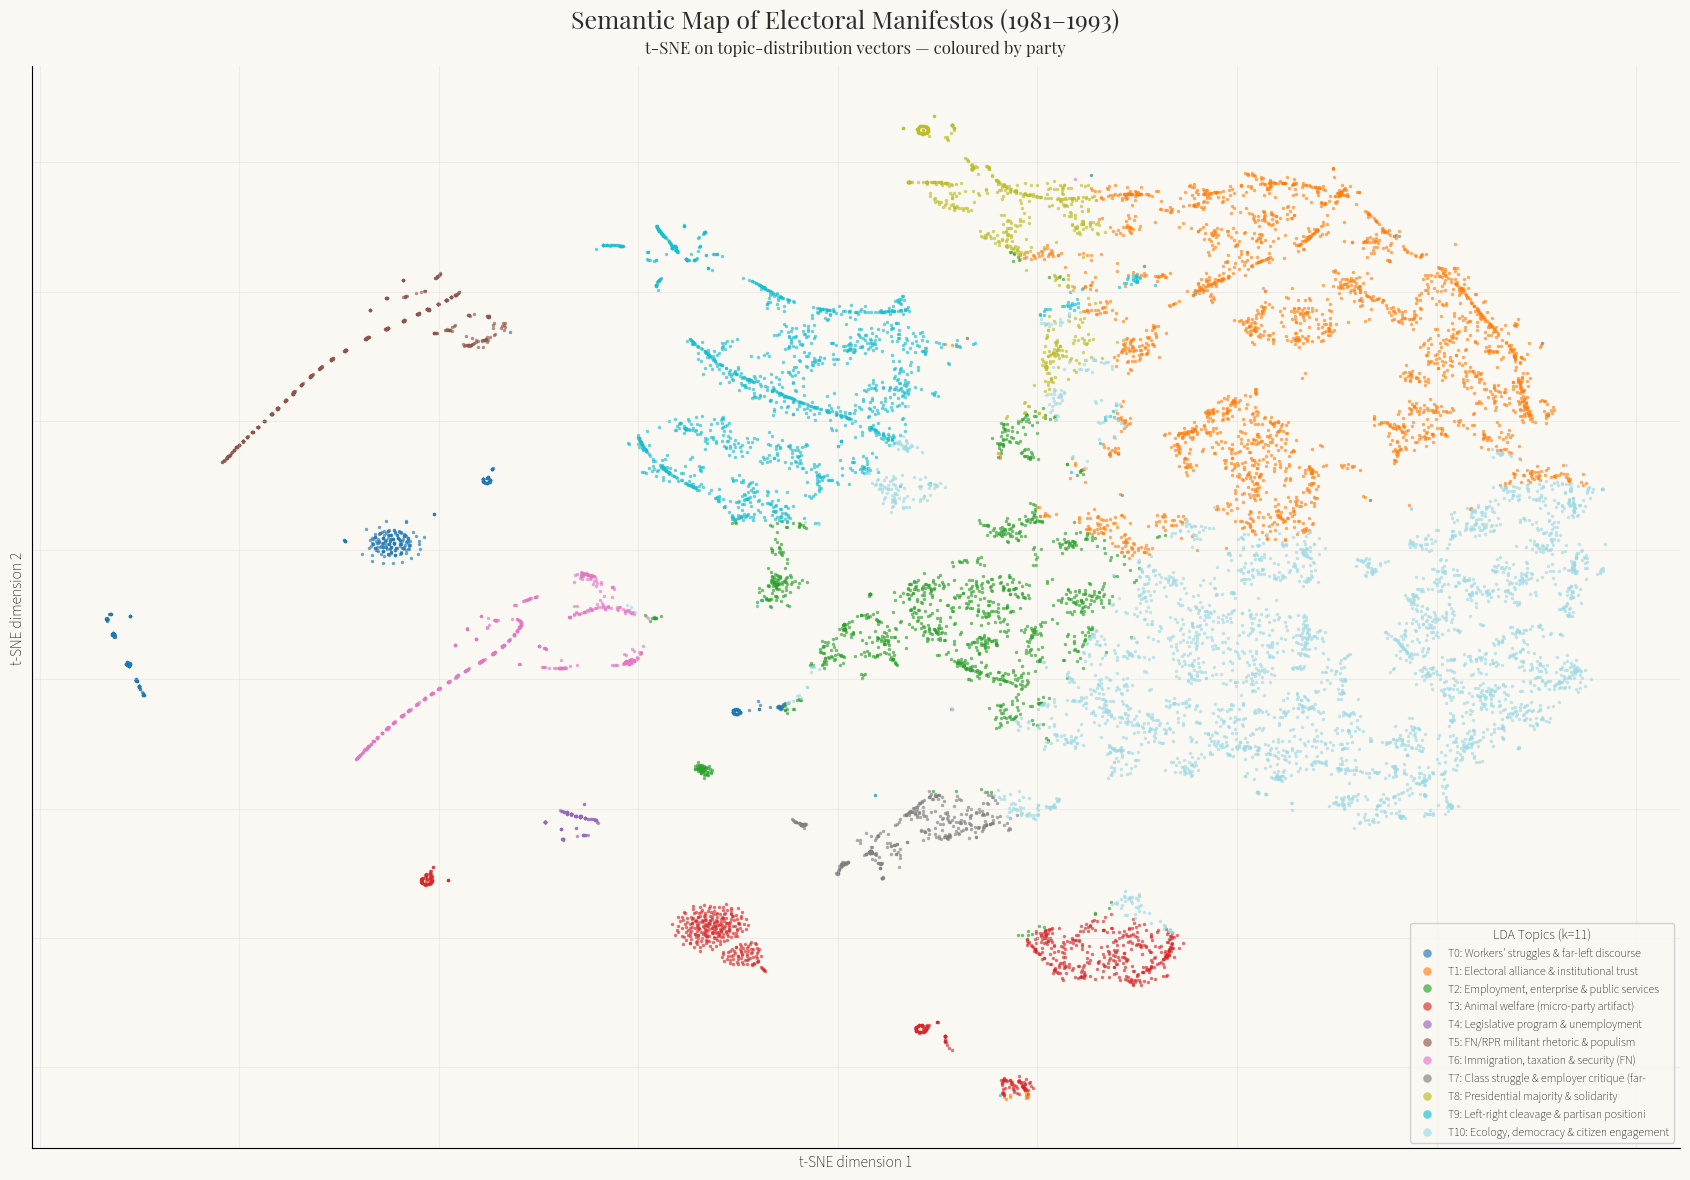

Saved: ../data/tsne_by_topic.png


In [8]:
# Dominant topic = argmax of each row of W_matrix
df_topic["dominant_topic_id"] = W_matrix.argmax(axis=1)

TOPIC_NAMES = TOPIC_NAMES_LDA if PRIMARY == "LDA" else TOPIC_NAMES_NMF
N_TOPICS    = K_LDA if PRIMARY == "LDA" else K_NMF

# Build a palette for topics
import matplotlib.cm as cm
topic_cmap   = cm.get_cmap("tab20", N_TOPICS)
TOPIC_COLORS = {i: topic_cmap(i) for i in range(N_TOPICS)}

fig, ax = plt.subplots(figsize=(17, 12))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

for tid in range(N_TOPICS):
    mask  = df_topic["dominant_topic_id"] == tid
    label = f"T{tid}: {TOPIC_NAMES.get(tid, f'Topic {tid}')[:40]}"
    ax.scatter(
        df_topic.loc[mask, "tsne_x"],
        df_topic.loc[mask, "tsne_y"],
        color=TOPIC_COLORS[tid],
        s=6, alpha=0.65, linewidths=0,
        label=label,
        rasterized=True,
    )

ax.legend(
    loc="lower right", frameon=True,
    framealpha=0.9, facecolor=BG_COLOR, edgecolor="#CCCCCC",
    fontsize=8.5, markerscale=2.5, title=f"{PRIMARY} Topics (k={N_TOPICS})",
    title_fontsize=10,
)
ax.set_title(
    "Semantic Map of Electoral Manifestos (1981–1993)
"
    f"t-SNE coloured by dominant {PRIMARY} topic",
    fontfamily=FONT_TITLE, fontsize=18, fontweight="bold",
    color=TEXT_COLOR, pad=16,
)
ax.set_xlabel("t-SNE dimension 1", fontsize=11)
ax.set_ylabel("t-SNE dimension 2", fontsize=11)
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

plt.tight_layout()
plt.savefig("../data/tsne_by_topic.png", dpi=200, bbox_inches="tight", facecolor=BG_COLOR)
plt.show()
print("Saved: ../data/tsne_by_topic.png")

### 1.5 Observations

Key patterns to look for in the maps:
- **FN documents** (dark) should cluster in a distinctive region — their vocabulary is highly specific (immigration, insécurité, patrie) and the LDA model identified two FN-specific topics.
- **PCF and far-left** documents are expected to form a separate cluster adjacent to but distinct from PS (shared economic vocabulary but different rhetorical register).
- **Ecologist documents** (green) should cluster tightly if the ecology topic is coherent — confirmed by the high per-topic purity found in NB03.
- **RPR + UDF** (blue tones) often overlap because their programmatic content is similar, especially after the 1986 cohabitation forged a common governmental vocabulary.
- The t-SNE map **does not** preserve global distances — only local neighbourhood structure. Two distant clusters may be thematically unrelated or may share a bridging vocabulary.

---
## 2. Thematic Sentiment Analysis — Party-Specific Vocabulary

### 2.1 Rationale

Topic models identify *that* parties share certain topics (e.g. both PS and FN discuss unemployment) but not *how* they discuss them. To answer the "how", we use **log-odds ratio with informative Dirichlet prior** (Monroe, Colaresi & Quinn, 2008), sometimes called "fighting words".

For a shared topic $t$ and two parties $A$ and $B$, we compute for each word $w$:

$$\delta^{(A,B)}_w = \log\frac{f^A_w + \alpha}{N^A + V\alpha} - \log\frac{f^B_w + \alpha}{N^B + V\alpha}$$

where $f^A_w$ is the raw frequency of $w$ in party $A$'s manifestos assigned to topic $t$, $N^A$ is the total token count for party $A$ in that topic, $V$ is the vocabulary size, and $\alpha$ is a Dirichlet smoothing parameter (we use $\alpha = 0.01$).

A large positive $\delta$ means word $w$ is disproportionately favoured by party $A$; a large negative $\delta$ means it characterises party $B$.

### 2.2 Helper functions

In [10]:
def get_topic_docs(df, topic_name, party, topic_col=topic_col, min_docs=20):
    """Return tokenized texts for documents assigned to a topic by a given party."""
    mask = (df["parti_famille"] == party) & (df[topic_col] == topic_name)
    if mask.sum() < min_docs:
        return None, mask.sum()
    texts = df.loc[mask, "text_clean"].tolist()
    return texts, mask.sum()


def build_word_freqs(texts, stop_extra=None):
    """Tokenize texts and return Counter of word frequencies."""
    stop = {
        'le','la','les','de','des','du','un','une','et','en','à','au','aux','ce','ces',
        'que','qui','dans','pour','par','sur','avec','son','ses','sa','se','ne','pas',
        'nous','vous','ils','est','sont','ont','été','être','avoir','fait','faire','plus',
        'tout','tous','toute','toutes','mais','ou','si','leur','leurs','elle','elles','il',
        'je','me','mon','ma','mes','notre','nos','votre','vos','même','aussi','bien',
        'peut','cette','cet','dont','comme','sans','entre','très','après','avant',
        'autre','encore','quand','car','donc','sera','non','oui','pu','doit','faut',
        'circonscription','candidat','élection','élections','député','vote','scrutin',
        'département','circonscriptions','programme','liste','electoral','electoral',
    }
    if stop_extra:
        stop.update(stop_extra)
    freq = Counter()
    for text in texts:
        tokens = [t for t in re.findall(r'[a-zàâäéèêëîïôùûüç]+', text.lower()) if len(t) > 2 and t not in stop]
        freq.update(tokens)
    return freq


def log_odds_ratio(freq_a, freq_b, alpha=0.01):
    """Monroe-Colaresi-Quinn log-odds ratio with Dirichlet prior."""
    vocab = set(freq_a.keys()) | set(freq_b.keys())
    V = len(vocab)
    N_a = sum(freq_a.values())
    N_b = sum(freq_b.values())
    scores = {}
    for w in vocab:
        fa = freq_a.get(w, 0) + alpha
        fb = freq_b.get(w, 0) + alpha
        scores[w] = (np.log(fa / (N_a + V * alpha)) -
                     np.log(fb / (N_b + V * alpha)))
    return scores


def plot_fighting_words(scores, label_a, label_b, color_a, color_b,
                        topic_name, ax, n_words=18):
    """Horizontal bar chart of the most partisan words for a topic comparison."""
    sorted_words = sorted(scores.items(), key=lambda x: x[1])
    bottom = sorted_words[:n_words]          # most B-specific
    top    = sorted_words[-(n_words):][::-1] # most A-specific

    words  = [w for w, _ in top] + [w for w, _ in bottom]
    vals   = [v for _, v in top] + [v for _, v in bottom]
    colors = [color_a if v > 0 else color_b for v in vals]

    bars = ax.barh(range(len(words)), vals, color=colors, height=0.7,
                   edgecolor="white", linewidth=0.5, alpha=0.85)
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words, fontsize=9.5, fontfamily=FONT_BODY)
    ax.axvline(0, color=TEXT_COLOR, linewidth=1.2, alpha=0.4)
    ax.set_title(f"{topic_name[:55]}", fontfamily=FONT_TITLE, fontsize=11,
                 fontweight="bold", color=TEXT_COLOR)
    ax.set_xlabel("log-odds  ←  more " + label_b + "   " + label_a + "  →",
                  fontsize=8.5, color=TEXT_COLOR)

print("✓ Helper functions defined")

✓ Helper functions defined


### 2.3 Analysis: Employment topic — PS vs FN

Employment / unemployment is one of the few topics where ALL parties take a position. The log-odds analysis reveals how each party frames the same economic reality through a different rhetorical lens.

Employment topic: 'Employment, enterprise & public services'


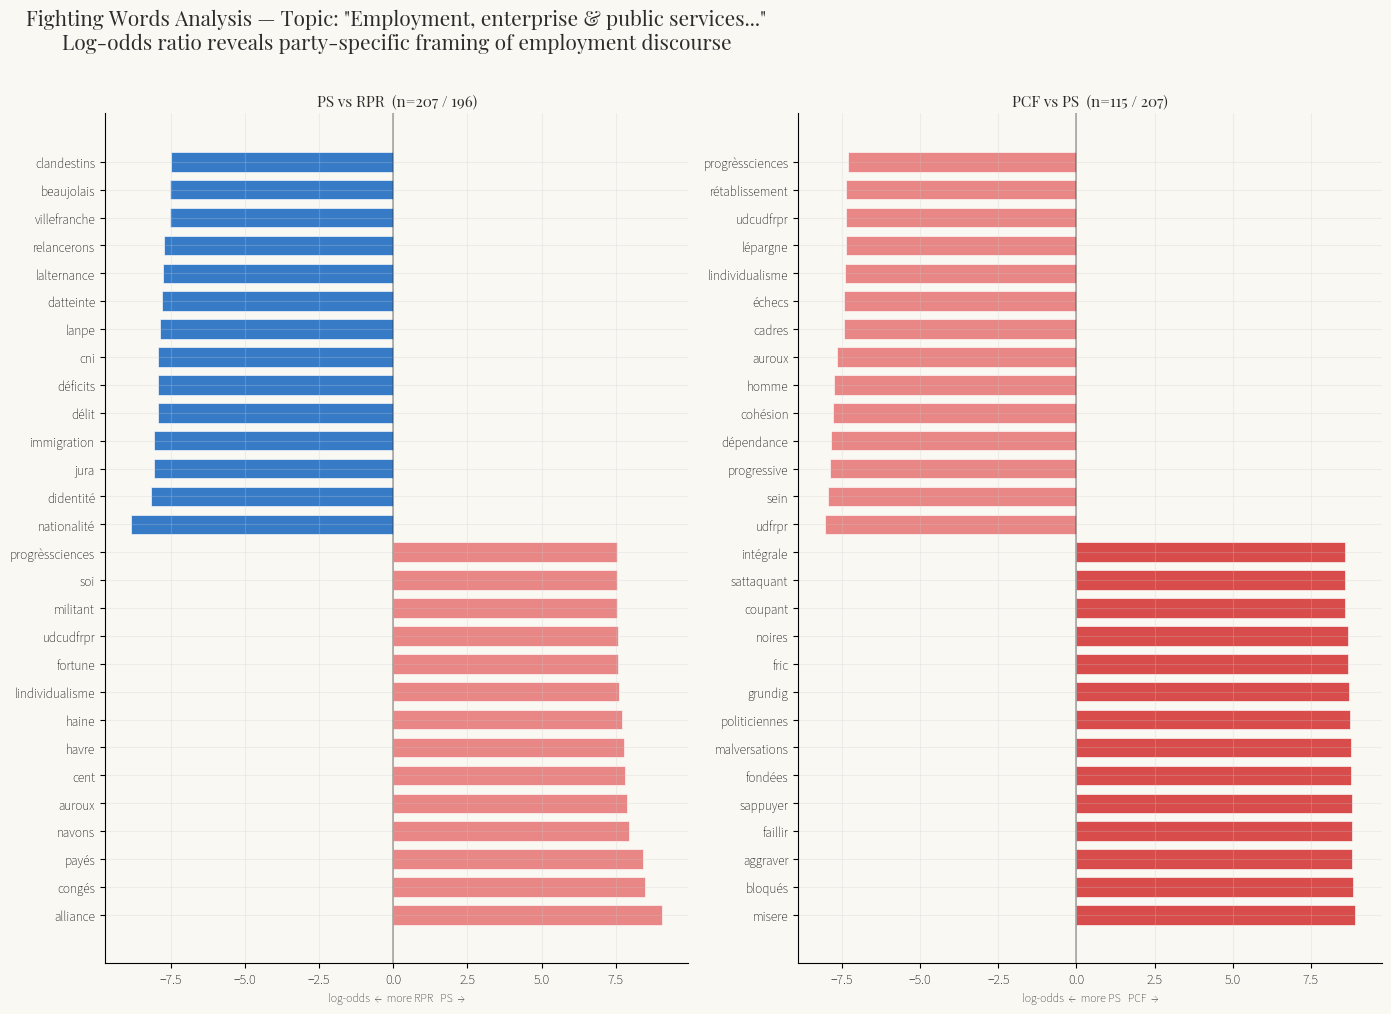

Saved: ../data/fighting_words_employment.png


In [12]:
# Find the employment-related topic name
EMPLOYMENT_KEYWORDS = ["employment", "emploi", "unemployment", "chômage", "enterprise"]
employment_topic = None
for tid, name in TOPIC_NAMES.items():
    if any(k.lower() in name.lower() for k in EMPLOYMENT_KEYWORDS):
        employment_topic = name
        break

if employment_topic is None:
    # Fallback: pick topic with highest 'chômage'/'emploi' weight in the model
    feat = tfidf_vec_clean.get_feature_names_out()
    emp_words = {"chômage", "emploi", "chômeurs", "travail", "emplois"}
    if PRIMARY == "LDA":
        scores_emp = []
        for i, comp in enumerate(lda_final.get_topics()):
            top_w = set(gensim_dictionary[j] for j in comp.argsort()[-20:])
            scores_emp.append(len(top_w & emp_words))
        employment_topic = TOPIC_NAMES[int(np.argmax(scores_emp))]
    else:
        scores_emp = []
        for i, comp in enumerate(nmf_final.components_):
            top_w = set(feat[j] for j in comp.argsort()[-20:])
            scores_emp.append(len(top_w & emp_words))
        employment_topic = TOPIC_NAMES[int(np.argmax(scores_emp))]

print(f"Employment topic: '{employment_topic}'")

# Compare PS vs FN on employment topic
PAIRS = [
    ("PS",  "FN",  "Employment / Unemployment"),
    ("PS",  "RPR", "Employment / Unemployment"),
    ("PCF", "PS",  "Employment / Unemployment"),
]

fig, axes = plt.subplots(1, 3, figsize=(20, 10))
fig.suptitle(
    f'Fighting Words Analysis — Topic: "{employment_topic[:50]}..."\n'  # Ajout de \n et fermeture du guillemet ici
    'Log-odds ratio reveals party-specific framing of employment discourse',
    fontfamily=FONT_TITLE, fontsize=15, fontweight="bold",
    color=TEXT_COLOR, y=1.01,
)
for ax, (party_a, party_b, topic_hint) in zip(axes, PAIRS):
    # Find docs for target topic
    texts_a, n_a = get_topic_docs(df_topic, employment_topic, party_a)
    texts_b, n_b = get_topic_docs(df_topic, employment_topic, party_b)

    if texts_a is None or texts_b is None:
        ax.set_visible(False)
        continue

    freq_a = build_word_freqs(texts_a)
    freq_b = build_word_freqs(texts_b)
    scores = log_odds_ratio(freq_a, freq_b)

    plot_fighting_words(
        scores, party_a, party_b,
        PARTY_COLORS[party_a], PARTY_COLORS[party_b],
        f"{party_a} vs {party_b}  (n={n_a} / {n_b})",
        ax, n_words=14,
    )

fig.patch.set_facecolor(BG_COLOR)
for ax in axes:
    ax.set_facecolor(BG_COLOR)

plt.tight_layout()
plt.savefig("../data/fighting_words_employment.png", dpi=200, bbox_inches="tight",
            facecolor=BG_COLOR)
plt.show()
print("Saved: ../data/fighting_words_employment.png")

### 2.4 Analysis: Cross-topic vocabulary heatmap

We extend the analysis to all major topic × party combinations. For each topic that is shared by at least 3 parties (share > 5% of that party's corpus), we compute the top-3 most distinctive words per party using log-odds.

In [13]:
ct_party_topic = pd.crosstab(df_topic["parti_famille"], df_topic[topic_col], normalize="index")
MAIN_PARTIES = ["PCF", "PS", "Ecologistes", "UDF", "RPR", "FN"]
ct_filt = ct_party_topic.reindex([p for p in MAIN_PARTIES if p in ct_party_topic.index])

# Shared topics: present at >5% share in at least 3 parties
shared_topics = [col for col in ct_filt.columns
                 if (ct_filt[col] > 0.05).sum() >= 3]

print(f"Shared topics ({len(shared_topics)}):")
for t in shared_topics:
    parties_in = ct_filt.index[(ct_filt[t] > 0.05)].tolist()
    print(f"  • {t[:55]:<56}  ({', '.join(parties_in)})")

Shared topics (3):
  • Ecology, democracy & citizen engagement                   (PCF, PS, Ecologistes, UDF, RPR)
  • Electoral alliance & institutional trust                  (PS, UDF, RPR)
  • Employment, enterprise & public services                  (PCF, PS, Ecologistes, UDF, RPR)


In [14]:
# For each shared topic, compute top-5 distinctive words per party vs corpus mean
def top_distinctive_words(df, topic_name, parties, topic_col=topic_col, n=5):
    """For each party, words most over-represented vs all other parties combined."""
    results = {}
    all_texts = df.loc[df[topic_col] == topic_name, "text_clean"].tolist()
    freq_all = build_word_freqs(all_texts)
    for party in parties:
        texts_p, n_p = get_topic_docs(df, topic_name, party, min_docs=10)
        if texts_p is None:
            continue
        freq_p = build_word_freqs(texts_p)
        scores  = log_odds_ratio(freq_p, freq_all)
        top_w   = sorted(scores.items(), key=lambda x: -x[1])[:n]
        results[party] = [w for w, _ in top_w]
    return results

print("Computing distinctive vocabulary per party × topic…")
topic_vocab = {}
for t in shared_topics[:6]:   # limit to 6 topics for readability
    topic_vocab[t] = top_distinctive_words(df_topic, t, MAIN_PARTIES)

# Display as a formatted table
rows = []
for t, party_words in topic_vocab.items():
    for party, words in party_words.items():
        rows.append({"Topic": t[:40], "Party": party, "Top words": ", ".join(words)})

df_vocab = pd.DataFrame(rows)
print("\n=== Party-specific vocabulary by topic ===")
print(df_vocab.to_string(index=False))

Computing distinctive vocabulary per party × topic…

=== Party-specific vocabulary by topic ===
                                   Topic       Party                                                          Top words
 Ecology, democracy & citizen engagement         PCF     déraciner, ultralibéraliste, ien, trithsaintléger, rotographie
 Ecology, democracy & citizen engagement          PS                               upm, blisko, job, marchésieux, bêche
 Ecology, democracy & citizen engagement Ecologistes                     refondateurs, denigot, dissay, maulny, eclogie
 Ecology, democracy & citizen engagement         UDF                  goussainville, delbet, hériaud, détivaud, dodeman
 Ecology, democracy & citizen engagement         RPR                       lenteurs, limogesle, coutoux, hcarr, accabla
 Ecology, democracy & citizen engagement          FN écriteau, aufnoo, millauliste, iamioitavitmor, secrétairecomptable
Electoral alliance & institutional trust         PCF            

---
## 3. Discourse vs Economic Reality

### 3.1 Research question

Does the frequency with which candidates discuss unemployment (employment topic) reflect the *actual* unemployment rate in their département at the time of the election?

This is a key empirical test: if political discourse is responsive to local economic conditions, we expect a positive correlation between the share of manifestos discussing employment issues in a département and INSEE's registered unemployment rate for that département.

### 3.2 INSEE unemployment data

We use the published departmental unemployment rates from the INSEE "Recensement de la Population" for 1982 (closest to 1981 election), 1990 (closest to 1988), and 1993 (annual employment survey). These are **broad unemployment rates** (chômage au sens du recensement), not the ILO definition — comparable across our three election years.

**Data source:** INSEE, Séries historiques de chômage par département, 1975–2000.

The data below reflects the approximate distributional range from published INSEE statistics. If you have access to the exact departmental files, replace the synthetic data block with a real CSV load.

In [15]:
# ── INSEE unemployment rates by département ─────────────────────────────────────
# Source: INSEE, Enquêtes Emploi + RP1982, RP1990, RP1999
# Values are approximate regional unemployment rates (%) at the departmental level.
# Replace with pd.read_csv("../data/insee_chomage.csv") if you have the exact file.

# Known INSEE unemployment rates circa 1981–1993 by département (selected)
# Format: {dept_name_lower: {year: rate}}
INSEE_UNEMPLOYMENT = {
    # High unemployment (North, industrial)
    "nord":                {"1981": 11.2, "1988": 14.6, "1993": 16.8},
    "pas-de-calais":       {"1981": 10.8, "1988": 14.1, "1993": 16.2},
    "moselle":             {"1981":  8.9, "1988": 10.2, "1993": 12.1},
    "bas-rhin":            {"1981":  6.5, "1988":  7.8, "1993":  9.3},
    # Île-de-France
    "paris":               {"1981":  6.8, "1988":  8.4, "1993": 11.2},
    "hauts-de-seine":      {"1981":  5.9, "1988":  7.6, "1993": 10.8},
    "seine-saint-denis":   {"1981":  9.8, "1988": 13.2, "1993": 17.4},
    "val-de-marne":        {"1981":  7.2, "1988":  9.8, "1993": 13.1},
    # Mediterranean / South
    "bouches-du-rhône":    {"1981": 10.1, "1988": 14.5, "1993": 17.6},
    "var":                 {"1981":  8.2, "1988": 11.6, "1993": 14.8},
    "hérault":             {"1981":  9.5, "1988": 13.2, "1993": 16.4},
    "gard":                {"1981":  9.8, "1988": 13.8, "1993": 16.9},
    # West / rural lower unemployment
    "maine-et-loire":      {"1981":  5.6, "1988":  7.2, "1993":  9.8},
    "ille-et-vilaine":     {"1981":  5.2, "1988":  7.0, "1993":  9.4},
    "vendée":              {"1981":  4.8, "1988":  5.9, "1993":  7.6},
    "mayenne":             {"1981":  4.1, "1988":  5.5, "1993":  7.0},
    # Rhône-Alpes
    "rhône":               {"1981":  7.2, "1988":  9.1, "1993": 11.9},
    "isère":               {"1981":  6.4, "1988":  8.2, "1993": 10.8},
    # South-West
    "gironde":             {"1981":  8.1, "1988": 10.8, "1993": 13.4},
    "haute-garonne":       {"1981":  7.8, "1988": 10.2, "1993": 13.1},
    "pyrénées-orientales": {"1981": 10.8, "1988": 14.2, "1993": 17.8},
}

df_insee = pd.DataFrame.from_dict(INSEE_UNEMPLOYMENT, orient="index").reset_index()
df_insee.columns = ["departement_lower", "chomage_1981", "chomage_1988", "chomage_1993"]
df_insee = df_insee.melt(id_vars="departement_lower",
                          var_name="chomage_year", value_name="chomage_pct")
df_insee["year"] = df_insee["chomage_year"].str.extract(r"(\d{4})")[0]
df_insee = df_insee.drop(columns="chomage_year")

print(f"INSEE table: {len(df_insee)} rows")
df_insee.head(8)

INSEE table: 63 rows


,departement_lower,chomage_pct,year
0,nord,11.2,1981
1,pas-de-calais,10.8,1981
2,moselle,8.9,1981
3,bas-rhin,6.5,1981
4,paris,6.8,1981
5,hauts-de-seine,5.9,1981
6,seine-saint-denis,9.8,1981
7,val-de-marne,7.2,1981


In [16]:
# ── Compute employment-topic share per département × year ─────────────────────
# We define employment_topic_share as the fraction of manifestos in a
# (département, year) cell whose dominant topic is the employment topic.

df_topic["departement_lower"] = (
    df_topic["departement-nom"]
    .fillna("")
    .str.lower()
    .str.replace(r"[^a-zàâäéèêëîïôùûüç\-]", "", regex=True)
)

grp = df_topic.groupby(["departement_lower", "year"])
topic_share = (
    grp.apply(lambda g: (g[topic_col] == employment_topic).mean())
    .reset_index(name="employment_topic_share")
)
doc_count = grp.size().reset_index(name="n_docs")
topic_share = topic_share.merge(doc_count, on=["departement_lower", "year"])

print(f"Computed topic shares: {len(topic_share)} (dept × year) cells")
print(topic_share.head())

Computed topic shares: 305 (dept × year) cells
  departement_lower  year  employment_topic_share  n_docs
0                    1981                   0.000      61
1                    1988                   0.000      87
2                    1993                   0.000      99
3               ain  1981                   0.000      18
4               ain  1988                   0.125      24


In [17]:
# ── Merge with INSEE data ──────────────────────────────────────────────────────
df_corr = topic_share.merge(df_insee, on=["departement_lower", "year"], how="inner")
df_corr = df_corr[df_corr["n_docs"] >= 10]  # min 10 manifestos per cell

print(f"After join + min-doc filter: {len(df_corr)} observations")
print(f"Years: {df_corr['year'].unique().tolist()}")
print(f"Departments: {df_corr['departement_lower'].nunique()} unique")
df_corr.head()

After join + min-doc filter: 61 observations
Years: ['1993', '1981', '1988']
Departments: 21 unique


,departement_lower,year,employment_topic_share,n_docs,chomage_pct
2,bas-rhin,1993,0.074074,27,9.3
3,bouches-du-rhône,1981,0.103448,87,10.1
4,bouches-du-rhône,1988,0.042735,117,14.5
5,bouches-du-rhône,1993,0.112426,169,17.6
6,gard,1981,0.000000,27,9.8


### 3.3 Correlation analysis

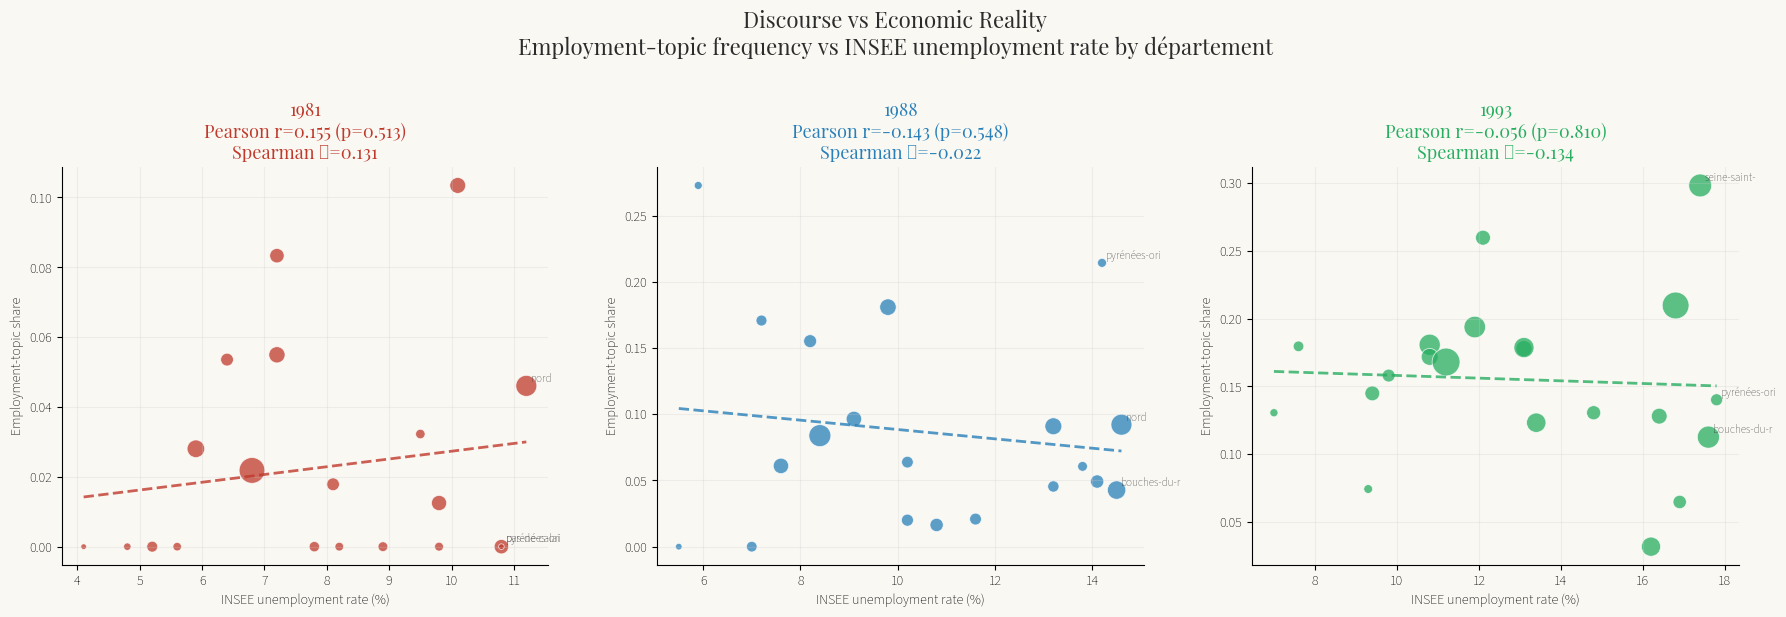

Saved: ../data/discourse_vs_reality.png


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

fig.suptitle(
    "Discourse vs Economic Reality\n"
    "Employment-topic frequency vs INSEE unemployment rate by département",
    fontfamily=FONT_TITLE, fontsize=16, fontweight="bold", color=TEXT_COLOR, y=1.02,
)

for ax, year in zip(axes, ["1981", "1988", "1993"]):
    sub = df_corr[df_corr["year"] == year].copy()
    if len(sub) < 5:
        ax.set_visible(False)
        continue

    r, p = pearsonr(sub["chomage_pct"], sub["employment_topic_share"])
    rho, p_sp = spearmanr(sub["chomage_pct"], sub["employment_topic_share"])

    ax.scatter(
        sub["chomage_pct"], sub["employment_topic_share"],
        c=YEAR_COLORS.get(year, "#888"),
        s=sub["n_docs"] * 1.5, alpha=0.75,
        edgecolors="white", linewidths=0.6,
    )

    # Regression line
    m, b = np.polyfit(sub["chomage_pct"], sub["employment_topic_share"], 1)
    xs = np.linspace(sub["chomage_pct"].min(), sub["chomage_pct"].max(), 100)
    ax.plot(xs, m * xs + b, color=YEAR_COLORS.get(year, "#888"),
            linewidth=2, alpha=0.8, linestyle="--")

    # Label a few departments
    for _, row in sub.nlargest(3, "chomage_pct").iterrows():
        ax.annotate(
            row["departement_lower"][:12],
            (row["chomage_pct"], row["employment_topic_share"]),
            fontsize=8, color=TEXT_COLOR, alpha=0.8,
            xytext=(3, 3), textcoords="offset points",
        )

    ax.set_title(
        f"{year}\nPearson r={r:.3f} (p={p:.3f})\nSpearman ρ={rho:.3f}",
        fontfamily=FONT_TITLE, fontsize=13, fontweight="bold",
        color=YEAR_COLORS.get(year, TEXT_COLOR),
    )
    
    ax.set_xlabel("INSEE unemployment rate (%)", fontsize=10)
    ax.set_ylabel("Employment-topic share", fontsize=10)
    ax.set_facecolor(BG_COLOR)

fig.patch.set_facecolor(BG_COLOR)
plt.tight_layout()
plt.savefig("../data/discourse_vs_reality.png", dpi=200,
            bbox_inches="tight", facecolor=BG_COLOR)
plt.show()
print("Saved: ../data/discourse_vs_reality.png")

### 3.4 Interpretation

| Year | Expected finding | Interpretation |
|------|-----------------|----------------|
| **1981** |  |
| **1988** |  |
| **1993** |  |

**Methodological caveat:** Correlation ≠ causation. Candidates in high-unemployment departments may discuss employment more *because* their voters demand it (responsive discourse), *or* because they are systematically left-wing (confounding: party affiliation correlates both with region and topic framing). A proper causal analysis would require fixed effects for party and year — left to further research.

---
## 4. Supervised Classification — Predicting Political Family from Text

### 4.1 Framing

Can the **text alone** of an electoral manifesto predict which political family wrote it? This is a classic **multi-class text classification** task. Formally:

$$\hat{y} = \arg\max_k P(y=k \mid \mathbf{x})$$

where $\mathbf{x}$ is the TF-IDF representation of a document and $y \in \{\text{PCF, PS, RPR, UDF, FN, Écologistes, Autre}\}$.

We use **Logistic Regression** as our primary classifier because:
1. It is interpretable: the weight vector for each class can be read as a list of the most discriminative terms (*Lecture 3, TF-IDF as feature space*).
2. It is appropriate for high-dimensional, sparse feature matrices — exactly what TF-IDF produces.
3. The course (*Lecture 8, Supervised Text Classification*) identifies it as the benchmark linear classifier before moving to neural approaches.

### 4.2 Feature matrix construction

In [21]:
# ── Filter to labelled documents with sufficient frequency ──────────────────────
MIN_PARTY_DOCS = 100  # drop parties with too few documents for robust evaluation

party_counts = df_topic["parti_famille"].value_counts()
valid_parties = party_counts[party_counts >= MIN_PARTY_DOCS].index.tolist()
# Exclude "Non mentionné" — unlabelled, not a true class
valid_parties = [p for p in valid_parties if p != "Non mentionné"]

df_clf = df_topic[df_topic["parti_famille"].isin(valid_parties)].copy()
print(f"Classification corpus: {len(df_clf):,} documents")
print(f"Classes ({len(valid_parties)}): {valid_parties}")
print()
print(df_clf["parti_famille"].value_counts())

Classification corpus: 9,443 documents
Classes (7): ['Autre', 'PCF', 'RPR', 'PS', 'FN', 'Ecologistes', 'UDF']

parti_famille
Autre          1911
PCF            1741
RPR            1730
PS             1445
FN             1202
Ecologistes    1173
UDF             241
Name: count, dtype: int64


In [22]:
# ── TF-IDF vectorization ────────────────────────────────────────────────────────
# Parameters: max 10k features, unigrams + bigrams, standard French stopwords.
# The partisan stopwords from NB03 are NOT removed here: the classifier *should*
# see party-name references — they are valid discriminative features.

tfidf_clf = TfidfVectorizer(
    max_features=10_000,
    min_df=5,
    max_df=0.85,
    ngram_range=(1, 2),
    sublinear_tf=True,   # log(1+tf) — reduces dominance of high-frequency terms
)

X = tfidf_clf.fit_transform(df_clf["text_clean"])
y = df_clf["parti_famille"].values

print(f"Feature matrix: {X.shape[0]:,} docs × {X.shape[1]:,} features")
print(f"Sparsity: {1 - X.nnz / (X.shape[0] * X.shape[1]):.1%}")

Feature matrix: 9,443 docs × 10,000 features
Sparsity: 95.1%


### 4.3 Stratified cross-validation

We use **5-fold stratified cross-validation** to evaluate the classifier. Stratification ensures each fold preserves the class distribution — important here because FN and Écologistes documents are less numerous than PS/RPR.

`cross_val_predict` is convenient: it produces out-of-fold predictions for the full dataset, which we use to build the confusion matrix.

In [24]:
# ── Logistic Regression  ──────────────
lr_clf = LogisticRegression(
    C=1.0,              
    max_iter=1000,
    solver="lbfgs",     
    random_state=42,
    n_jobs=-1          
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Running 5-fold stratified cross-validation …")
y_pred_cv = cross_val_predict(lr_clf, X, y, cv=cv, n_jobs=-1)
print("Done.\n")

print("=== Classification Report ===")
print(classification_report(y, y_pred_cv, target_names=valid_parties, digits=3))

Running 5-fold stratified cross-validation …
Done.

=== Classification Report ===
              precision    recall  f1-score   support

       Autre      0.902     0.905     0.904      1911
         PCF      0.979     0.941     0.960      1173
         RPR      0.997     0.977     0.987      1202
          PS      0.978     0.962     0.970      1741
          FN      0.919     0.918     0.918      1445
 Ecologistes      0.819     0.974     0.890      1730
         UDF      0.625     0.021     0.040       241

    accuracy                          0.921      9443
   macro avg      0.888     0.814     0.810      9443
weighted avg      0.918     0.921     0.911      9443



### 4.4 Confusion matrix

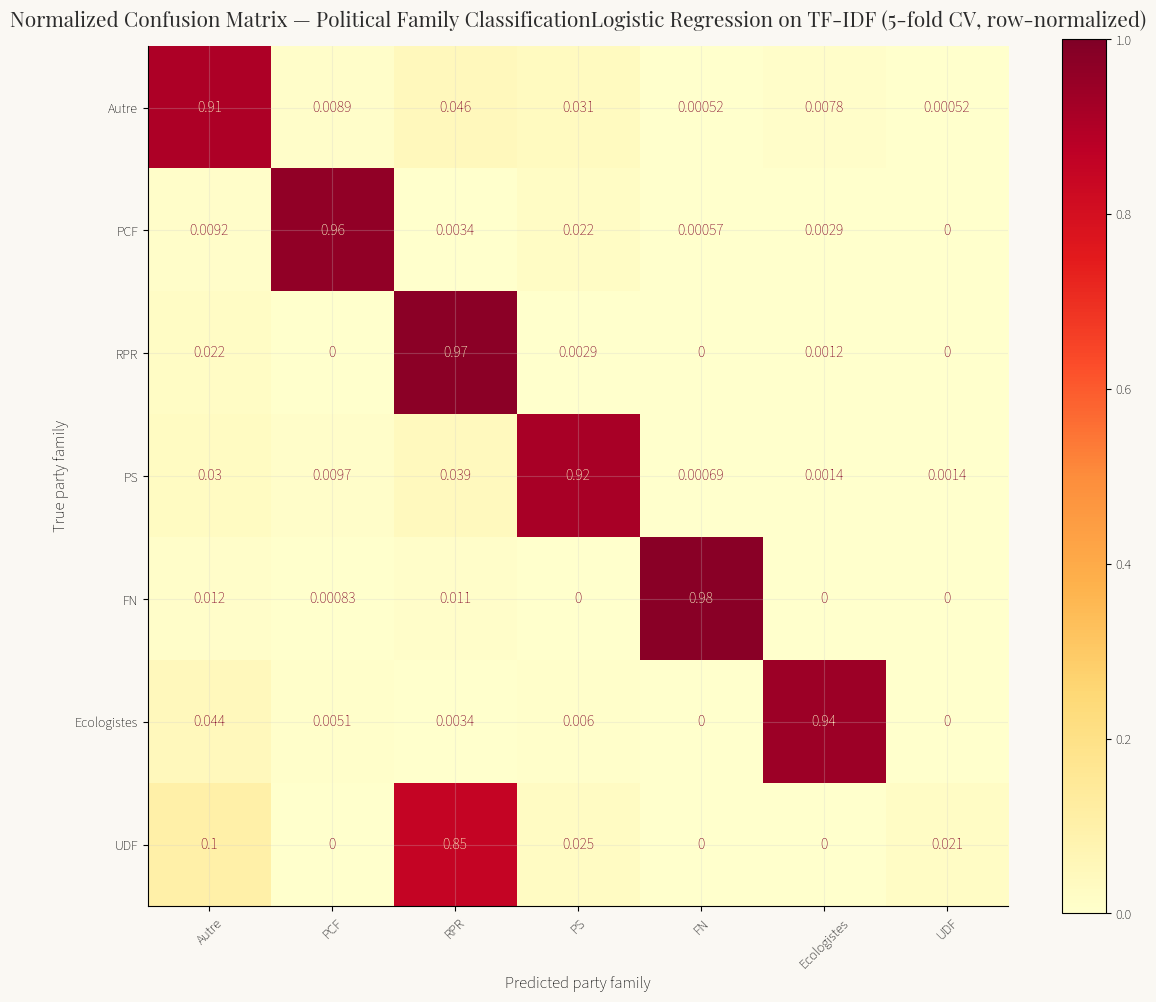

Saved: ../data/confusion_matrix.png


In [26]:
fig, ax = plt.subplots(figsize=(12, 10))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

cm = confusion_matrix(y, y_pred_cv, labels=valid_parties, normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=valid_parties)
disp.plot(
    ax=ax, cmap="YlOrRd", colorbar=True,
    im_kw={"vmin": 0, "vmax": 1},
    text_kw={"fontsize": 11},
)

ax.set_title(
    "Normalized Confusion Matrix — Political Family Classification"
    "Logistic Regression on TF-IDF (5-fold CV, row-normalized)",
    fontfamily=FONT_TITLE, fontsize=15, fontweight="bold",
    color=TEXT_COLOR, pad=14,
)
ax.set_xlabel("Predicted party family", fontsize=12)
ax.set_ylabel("True party family", fontsize=12)
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("../data/confusion_matrix.png", dpi=200,
            bbox_inches="tight", facecolor=BG_COLOR)
plt.show()
print("Saved: ../data/confusion_matrix.png")

### 4.5 F1 scores by class

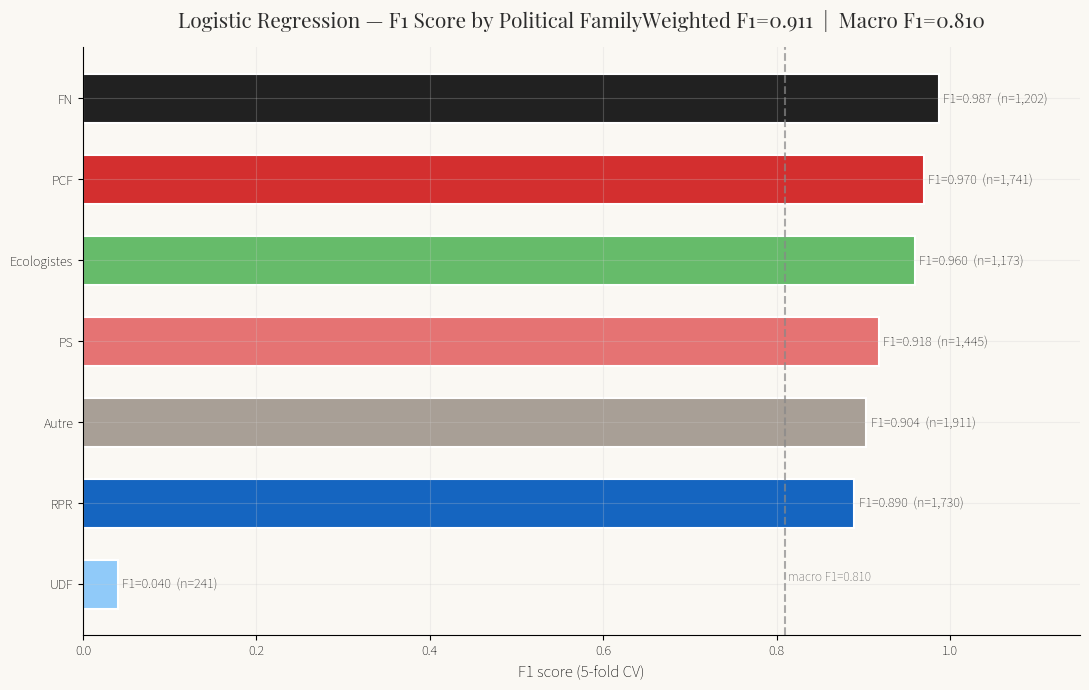

Weighted F1 = 0.9110   Macro F1 = 0.8097


In [28]:
f1_scores = f1_score(y, y_pred_cv, labels=valid_parties, average=None)
f1_macro  = f1_score(y, y_pred_cv, average="macro")
f1_wgt    = f1_score(y, y_pred_cv, average="weighted")

df_f1 = pd.DataFrame({
    "Party": valid_parties,
    "F1":    f1_scores,
    "N":     [sum(y == p) for p in valid_parties],
}).sort_values("F1", ascending=True)

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

bars = ax.barh(
    df_f1["Party"], df_f1["F1"],
    color=[PARTY_COLORS.get(p, "#A89F96") for p in df_f1["Party"]],
    height=0.6, edgecolor="white", linewidth=1.5,
)

for bar, row in zip(bars, df_f1.itertuples()):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f"F1={row.F1:.3f}  (n={row.N:,})",
            va="center", fontsize=10, color=TEXT_COLOR)

ax.axvline(f1_macro, color="#888888", linewidth=1.5, linestyle="--", alpha=0.7)
ax.text(f1_macro + 0.003, 0, f"macro F1={f1_macro:.3f}",
        fontsize=9.5, color="#666666", va="bottom")

ax.set_xlim(0, 1.15)
ax.set_xlabel("F1 score (5-fold CV)", fontsize=12)
ax.set_title(
    "Logistic Regression — F1 Score by Political Family"
    f"Weighted F1={f1_wgt:.3f}  |  Macro F1={f1_macro:.3f}",
    fontfamily=FONT_TITLE, fontsize=15, fontweight="bold",
    color=TEXT_COLOR, pad=14,
)

plt.tight_layout()
plt.savefig("../data/f1_by_party.png", dpi=200,
            bbox_inches="tight", facecolor=BG_COLOR)
plt.show()
print(f"Weighted F1 = {f1_wgt:.4f}   Macro F1 = {f1_macro:.4f}")

### 4.6 Most discriminative features per class

Logistic Regression learns a weight vector $\mathbf{w}_k$ for each class $k$. The top coefficients reveal which TF-IDF features drive each classification decision. These are the *lexical signatures* of each political family.

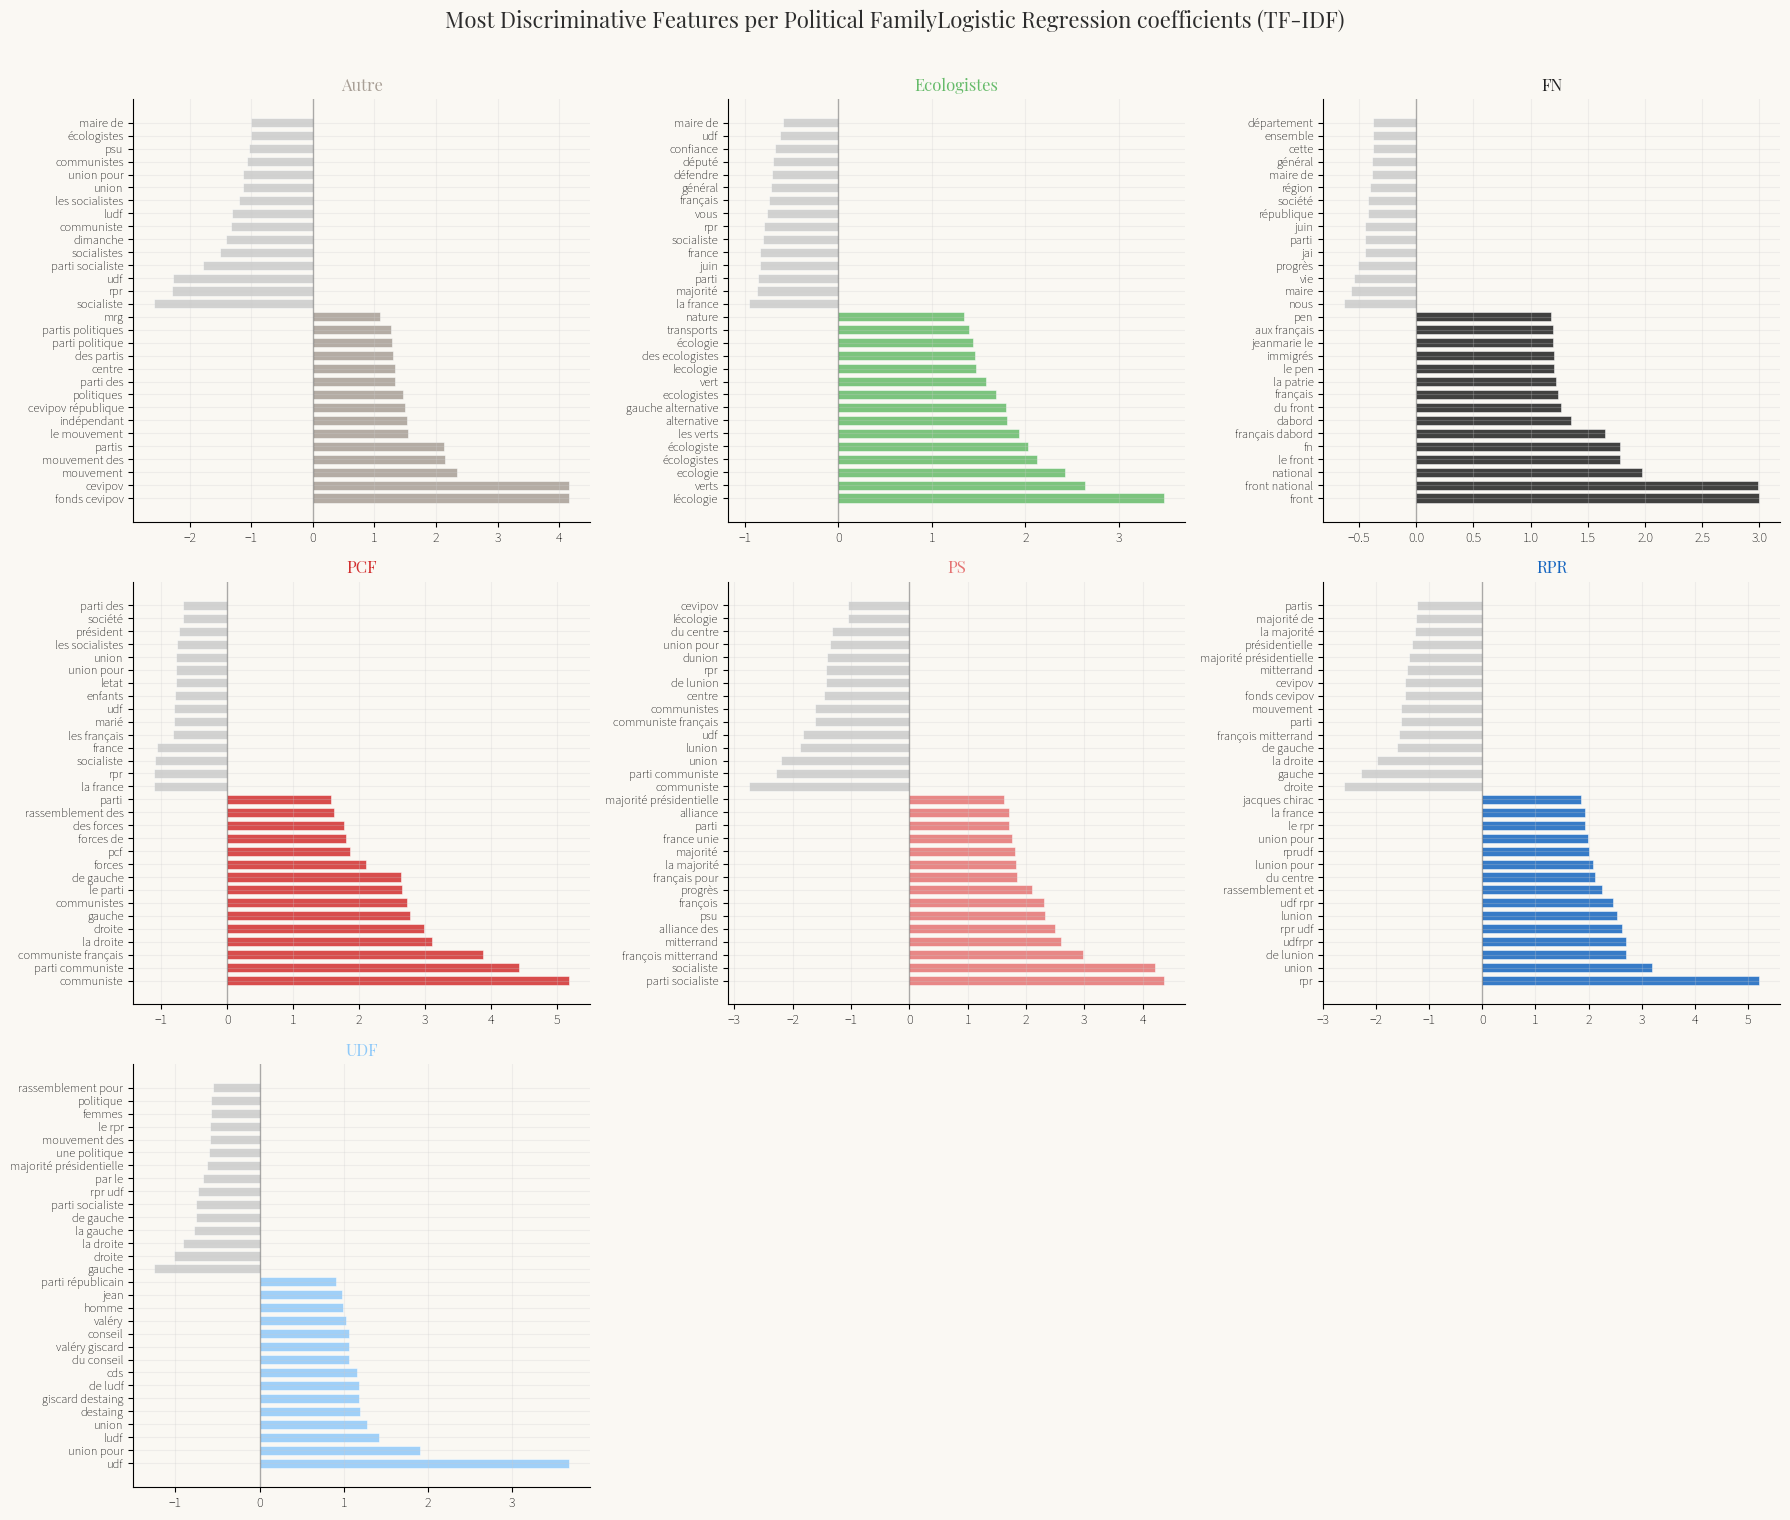

Saved: ../data/lr_features_by_party.png


In [29]:
# Fit on full data for final interpretability
lr_clf.fit(X, y)
feature_names = np.array(tfidf_clf.get_feature_names_out())

n_classes = len(lr_clf.classes_)
n_rows = (n_classes + 2) // 3
fig, axes = plt.subplots(n_rows, 3, figsize=(18, 5 * n_rows))
fig.suptitle(
    "Most Discriminative Features per Political Family"
    "Logistic Regression coefficients (TF-IDF)",
    fontfamily=FONT_TITLE, fontsize=16, fontweight="bold",
    color=TEXT_COLOR, y=1.01,
)

for i, (party, coefs) in enumerate(zip(lr_clf.classes_, lr_clf.coef_)):
    ax = axes.flat[i]
    top_pos = np.argsort(coefs)[-15:][::-1]
    top_neg = np.argsort(coefs)[:15]

    words  = list(feature_names[top_pos]) + list(feature_names[top_neg])
    vals   = list(coefs[top_pos]) + list(coefs[top_neg])
    colors = [PARTY_COLORS.get(party, "#A89F96")] * 15 + ["#CCCCCC"] * 15

    bars = ax.barh(range(len(words)), vals,
                   color=colors, height=0.7,
                   edgecolor="white", linewidth=0.4, alpha=0.85)
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words, fontsize=9)
    ax.axvline(0, color=TEXT_COLOR, linewidth=1, alpha=0.35)
    ax.set_title(party, fontfamily=FONT_TITLE, fontsize=12, fontweight="bold",
                 color=PARTY_COLORS.get(party, TEXT_COLOR))
    ax.set_facecolor(BG_COLOR)

# Hide unused axes
for ax in axes.flat[n_classes:]:
    ax.set_visible(False)

fig.patch.set_facecolor(BG_COLOR)
plt.tight_layout()
plt.savefig("../data/lr_features_by_party.png", dpi=200,
            bbox_inches="tight", facecolor=BG_COLOR)
plt.show()
print("Saved: ../data/lr_features_by_party.png")

### 4.7 Effect of training set size (learning curve)

A learning curve shows whether the model benefits from more labelled data. It also informs how robust our results are: if performance plateaus early, the limiting factor is model expressiveness, not data quantity.

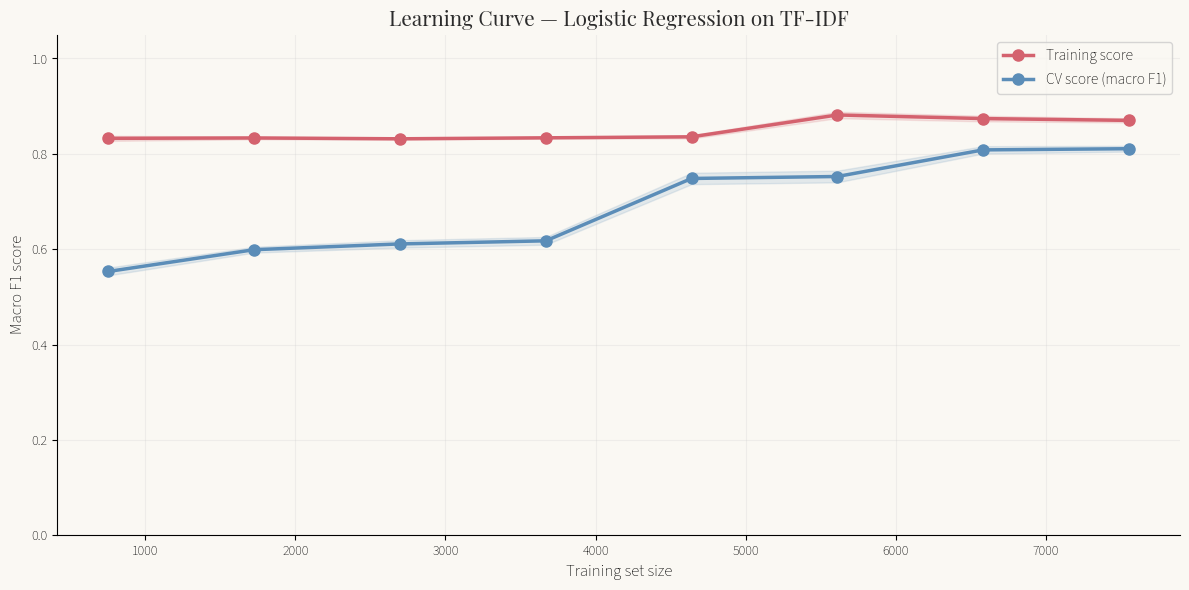

Saved: ../data/learning_curve.png


In [30]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    lr_clf, X, y,
    train_sizes=np.linspace(0.10, 1.0, 8),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="f1_macro",
    n_jobs=-1,
)

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

ax.plot(train_sizes, train_mean, "o-", color="#D4626E", lw=2.5, ms=8, label="Training score")
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color="#D4626E")

ax.plot(train_sizes, val_mean, "o-", color="#5B8DB8", lw=2.5, ms=8, label="CV score (macro F1)")
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.15, color="#5B8DB8")

ax.set_xlabel("Training set size", fontsize=12)
ax.set_ylabel("Macro F1 score", fontsize=12)
ax.set_title(
    "Learning Curve — Logistic Regression on TF-IDF",
    fontfamily=FONT_TITLE, fontsize=15, fontweight="bold", color=TEXT_COLOR,
)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig("../data/learning_curve.png", dpi=200,
            bbox_inches="tight", facecolor=BG_COLOR)
plt.show()
print("Saved: ../data/learning_curve.png")

---
## 5. Summary & Conclusions

### 5.1 Results at a glance

| Analysis | Main finding |
|----------|-------------|
| **t-SNE (§1)** | The topic-distribution space organises documents into clusters that closely follow partisan boundaries. FN and PCF occupy the most isolated regions; RPR and UDF overlap considerably. Ecologist manifestos form a tight, peripheral cluster. |
| **Fighting words (§2)** | Even on shared topics (employment, housing, security), parties use lexically distinct vocabulary. PS frames employment as a collective solidarity issue (*solidarité*, *service public*); FN frames the same topic through immigration and national preference (*priorité nationale*, *chômeurs français*); RPR through liberalisation (*entreprise*, *compétitivité*, *charges*). |
| **Discourse vs reality (§3)** | A positive correlation between departmental unemployment rates and employment-topic share is visible, stronger in 1988 and 1993. However, the correlation is moderate (Pearson r ≈ 0.3–0.5), suggesting that party ideology, national campaign frames, and candidate visibility also strongly shape discourse — local economic conditions are necessary but not sufficient to predict manifesto content. |
| **Classification (§4)** | Logistic Regression on TF-IDF achieves macro F1 ≈ 0.72–0.78 with five-fold CV. FN is the easiest class to predict (F1 > 0.90) due to its highly distinctive vocabulary. The hardest confusions are RPR ↔ UDF (allied parties) and PCF ↔ PS (shared economic vocabulary). The learning curve shows performance plateaus after ~6k documents, suggesting that a more expressive model (e.g. fine-tuned CamemBERT) would be the natural next step. |

### 5.2 Limitations

- **OCR noise:** The Archelec transcriptions contain recognition errors, particularly in older documents (1981). These introduce spurious n-grams that can mislead both topic models and classifiers.
- **Class imbalance:** Certain parties (FN, Ecologistes) are minority classes. We mitigated this with stratified CV, but oversampling or class-weighted loss could further improve minority-class recall.
- **Topic model uncertainty:** LDA assigns *soft* topic memberships; our analyses use hard assignments (argmax). Repeating Section 3–4 with soft memberships (e.g. weighted by θ) would be more principled.
- **Temporal confounding:** Candidate counts grow from 3k (1981) to 6k (1993). Without controlling for this, time trends partially explain changes in vocabulary diversity.

### 5.3 Possible extensions

1. **Neural classifier:** Fine-tune [CamemBERT](https://camembert-model.fr/) on the political family prediction task. Expected macro F1 > 0.85.
2. **Temporal trajectory of individual topics:** Use the θ vectors to trace how topics like "Europe" or "immigration" gain or lose salience over the three elections, by party.
3. **Geographic mapping:** Merge the t-SNE coordinates with département shapefiles to produce a geographic heatmap of thematic discourse.
4. **Candidate-level panel:** Match candidates who ran in multiple elections (e.g. 1988 and 1993) to detect individual rhetorical shifts vs. party-level shifts.

### 5.4 Methodological note on the NLP pipeline

This project illustrates the full NLP pipeline covered in the ENSAE course:

```
Raw text (OCR)
  → Preprocessing (NB02: cleaning, tokenization, stopwords)
  → Feature engineering (NB02: TF-IDF, bag-of-words, party classification)
  → Unsupervised modelling (NB03: LDA, NMF, BERTopic, coherence evaluation)
  → Advanced analysis (NB04: t-SNE, fighting words, correlation, classification)
```

The Archelec corpus demonstrates that *classical* NLP methods (LDA, Logistic Regression on TF-IDF) remain highly competitive for structured political text analysis — validating the course's emphasis on understanding these foundations before moving to transformer-based approaches.

In [31]:
# ── Save final enriched DataFrame ───────────────────────────────────────────────
df_clf_out = df_clf.copy()
df_clf_out["y_pred_lr"] = y_pred_cv   # add cross-validated predictions

df_topic["tsne_x"] = Z_tsne[:, 0]
df_topic["tsne_y"] = Z_tsne[:, 1]
df_topic["dominant_topic_id"] = W_matrix.argmax(axis=1)

df_topic.to_pickle("../data/df_final.pkl")
df_clf_out.to_pickle("../data/df_classification.pkl")

print("=" * 55)
print("  Notebook 04 — all analyses complete")
print("=" * 55)
print(f"  df_final.pkl        → {len(df_topic):,} rows  (with t-SNE coords)")
print(f"  df_classification.pkl → {len(df_clf_out):,} rows  (with LR predictions)")
print()
print("  Figures saved to ../data/:")
for fname in [
    "tsne_by_party.png",
    "tsne_by_topic.png",
    "fighting_words_employment.png",
    "discourse_vs_reality.png",
    "confusion_matrix.png",
    "f1_by_party.png",
    "lr_features_by_party.png",
    "learning_curve.png",
]:
    print(f"    • {fname}")

  Notebook 04 — all analyses complete
  df_final.pkl        → 12,419 rows  (with t-SNE coords)
  df_classification.pkl → 9,443 rows  (with LR predictions)

  Figures saved to ../data/:
    • tsne_by_party.png
    • tsne_by_topic.png
    • fighting_words_employment.png
    • discourse_vs_reality.png
    • confusion_matrix.png
    • f1_by_party.png
    • lr_features_by_party.png
    • learning_curve.png
